# Part 5

In [4]:
import redis
import pandas as pd
import matplotlib.pyplot as plt

REDIS_KEY_PREFIX = 'journey:gyro'

r = redis.Redis(host='localhost', port=6379)
keys = r.keys(f'{REDIS_KEY_PREFIX}:*')
print(f"Gefundene Keys in Redis: {len(keys)}")

Gefundene Keys in Redis: 38


In [5]:
records = []
for key in keys:
    data = r.hgetall(key)
    decoded = {k.decode('utf-8'): v.decode('utf-8') for k, v in data.items()}
    records.append(decoded)

df = pd.DataFrame(records)
df['avg_absolute']  = df['avg_absolute'].astype(float)
df['avg_gx']        = df['avg_gx'].astype(float)
df['avg_gy']        = df['avg_gy'].astype(float)
df['avg_gz']        = df['avg_gz'].astype(float)
df['n_samples']     = df['n_samples'].astype(int)
df['fenster_start'] = pd.to_datetime(df['fenster_start'])
df = df.sort_values('fenster_start').reset_index(drop=True)

print(f"Geladene Fenster: {len(df)}")
df[['fenster_start', 'avg_gx', 'avg_gy', 'avg_gz', 'avg_absolute', 'n_samples']].head(10)

Geladene Fenster: 38


,fenster_start,avg_gx,avg_gy,avg_gz,avg_absolute,n_samples
0,2026-05-30 17:07:40,1.159208,-0.004333,0.109810,1.190905,99
1,2026-05-30 17:07:41,1.244301,-0.046983,0.014471,1.406680,100
2,2026-05-30 17:07:42,-2.681013,-0.069460,-0.013465,2.752703,99
3,2026-05-30 17:07:43,-1.103389,0.002712,0.092138,1.307978,99
4,2026-05-30 17:07:44,-0.106704,0.049521,1.528658,1.698974,100
5,2026-05-30 17:07:45,0.242705,-0.013159,-2.412425,2.549243,99
6,2026-05-30 17:07:46,-0.172340,-0.073048,-0.677537,1.340450,99
7,2026-05-30 17:07:47,-0.052018,0.054296,2.473567,2.586726,100
8,2026-05-30 17:07:48,0.015763,0.070285,0.179866,1.068430,99
9,2026-05-30 17:07:49,0.036378,-0.081072,-1.247987,1.411700,99


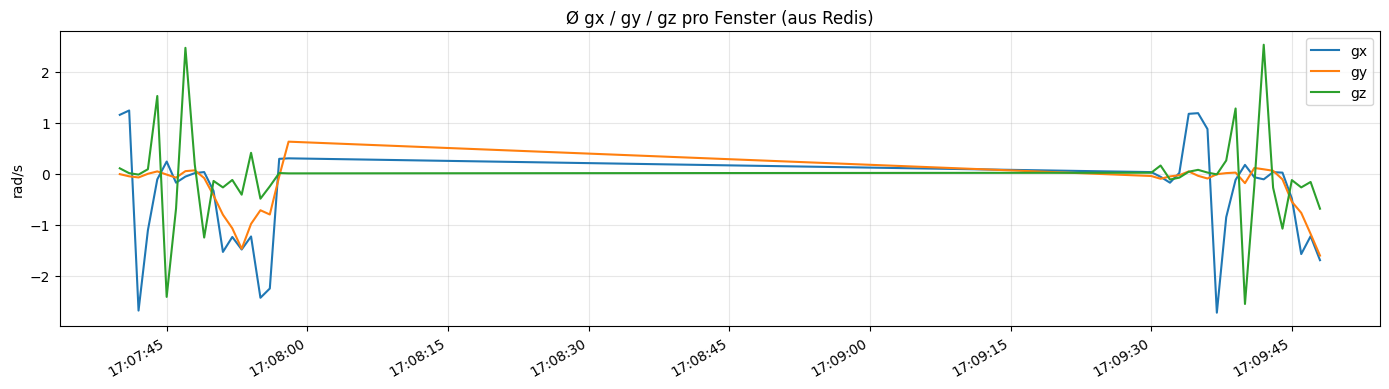

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['fenster_start'], df['avg_gx'], label='gx')
ax.plot(df['fenster_start'], df['avg_gy'], label='gy')
ax.plot(df['fenster_start'], df['avg_gz'], label='gz')
ax.set_title('Ø gx / gy / gz pro Fenster (aus Redis)')
ax.set_ylabel('rad/s')
ax.legend()
ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
